# Preparación y exploración de Amazon Reviews 2023 · Electronics

Copia esta notebook y [datasets](./datasets/) a tu proyecto `uv`. Explora los
**600 productos y 6 992 reseñas** antes de implementar las herramientas MCP.
La selección está preparada; la sección 8 explica su generación como referencia
opcional. Las gráficas utilizan barras e histogramas vistos en clase.


In [1]:
import gzip
import json
import urllib.request
from collections.abc import Iterator
from pathlib import Path
from typing import Any, TypedDict

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("datasets")
if not DATA_DIR.exists() and Path("proyecto-final/datasets").exists():
    DATA_DIR = Path("proyecto-final/datasets")


## 1. Usar los archivos proporcionados

`ensure_data()` comprueba que estén ambos archivos. Puedes adaptar las funciones
de lectura en `support/data.py`.


In [2]:
def ensure_data(directory: Path) -> None:
    for filename in ("reviews.jsonl.gz", "products.jsonl.gz"):
        if not (directory / filename).is_file():
            raise FileNotFoundError(f"Copy the provided datasets folder first: {filename}")

ensure_data(DATA_DIR)


## 2. Leer JSONL comprimido

Cada línea contiene un objeto JSON independiente. `gzip.open(..., "rt")` abre el
archivo comprimido como texto; `json.loads()` convierte cada línea en un diccionario.
`rows()` devuelve el número de línea del archivo pequeño junto con el registro.


In [3]:
def rows(path: Path) -> Iterator[tuple[int, dict[str, Any]]]:
    with gzip.open(path, "rt", encoding="utf-8") as stream:
        for line_number, text in enumerate(stream, start=1):
            if text.strip():
                yield line_number, json.loads(text)


first_line, first_review = next(rows(DATA_DIR / "reviews.jsonl.gz"))
print("Subset line:", first_line)
print("Original line:", first_review["source_line"])
print("Product:", first_review["parent_asin"])
print("Rating:", first_review["rating"])
print("Text:", first_review["text"][:200])


Subset line: 1
Original line: 1039
Product: B0000BYDKO
Rating: 2.0
Text: Doesn't work very good at all. The cheap plastic is hard to turn  with the weight of the hose.


## 3. Preparar registros para la aplicación

`parent_asin` identifica al producto. `source_line` conserva la línea del archivo
original y permite IDs de reseña estables como `Electronics:123`.
Los `TypedDict` describen los registros; `load()` revisa los campos al leerlos.


In [4]:
class ReviewRecord(TypedDict):
    review_id: str
    product_id: str
    text: str
    rating: float


class ProductRecord(TypedDict):
    product_id: str
    title: str
    features: list[str]
    description: list[str]
    categories: list[str]
    family: str


def load(directory: Path) -> tuple[list[ReviewRecord], dict[str, ProductRecord]]:
    products: dict[str, ProductRecord] = {}
    for line_number, product in rows(directory / "products.jsonl.gz"):
        product_id = product.get("parent_asin")
        title = product.get("title") or ""
        if not isinstance(product_id, str) or not product_id.strip():
            raise ValueError(f"Invalid product ID at line {line_number}")
        if not isinstance(title, str):
            raise ValueError(f"Invalid product title at line {line_number}")
        if product_id in products:
            raise ValueError(f"Duplicate product ID at line {line_number}")
        features = product.get("features") or []
        if not isinstance(features, list) or any(not isinstance(item, str) for item in features):
            raise ValueError(f"Invalid features at line {line_number}")
        description = product.get("description") or []
        categories = product.get("categories") or []
        family = product.get("family")
        for values in (description, categories):
            if not isinstance(values, list) or any(not isinstance(item, str) for item in values):
                raise ValueError(f"Invalid catalog text at line {line_number}")
        if not isinstance(family, str) or not family:
            raise ValueError(f"Invalid family at line {line_number}")
        products[product_id] = {
            "product_id": product_id, "title": title, "features": features,
            "description": description, "categories": categories, "family": family,
        }

    records: list[ReviewRecord] = []
    for line_number, review in rows(directory / "reviews.jsonl.gz"):
        product_id = review.get("parent_asin")
        rating = review.get("rating")
        text = review.get("text") or ""
        if not isinstance(product_id, str) or not product_id.strip():
            raise ValueError(f"Invalid product ID at review line {line_number}")
        if isinstance(rating, bool) or not isinstance(rating, (int, float)):
            raise ValueError(f"Invalid rating at review line {line_number}")
        if rating not in (1, 2, 3, 4, 5) or not isinstance(text, str):
            raise ValueError(f"Invalid review at line {line_number}")
        source_line = review.get("source_line")
        if isinstance(source_line, bool) or not isinstance(source_line, int) or source_line < 1:
            raise ValueError(f"Invalid original line at review line {line_number}")
        records.append({
            "review_id": f"Electronics:{source_line}",
            "product_id": product_id,
            "text": text,
            "rating": float(rating),
        })
    return records, products



records, products = load(DATA_DIR)
reviews_df = pd.DataFrame(records)
products_df = pd.DataFrame(list(products.values())).rename(columns={"title": "product_title"})
print("Reviews:", len(reviews_df))
print("Products:", len(products_df))
products_df[["product_id", "product_title", "family"]].head()


Reviews: 6992
Products: 600


,product_id,product_title,family
0,B0000BYDKO,Cord Storage Reel w/Stand,Accessories
1,B000GU88CQ,OM Digital Solutions TP-7 Telephone pick up,Audio
2,B001CQT0X4,Kingston 8 GB microSDHC Class 4 Flash Memory C...,Computing
3,B00A36QZ1Y,"Fotodiox Metal Step Up Ring, Anodized Black Me...",Photography
4,B000BSKOXE,Channel Master 3079 Antenna Mount Kit - 2 Pack,TV & video


## 4. Relacionar reseñas y catálogo

La unión usa el ID del producto. `validate="many_to_one"` comprueba que el catálogo
contenga una fila por producto. Todos los productos de esta selección tienen catálogo.
Para búsqueda utilizaremos título, características y descripción cuando exista.


In [5]:
review_catalog = reviews_df.merge(
    products_df, on="product_id", how="left", validate="many_to_one", indicator=True
)
print("Reviews without catalog:", int((review_catalog["_merge"] == "left_only").sum()))
products_df["catalog_text"] = (
    products_df["product_title"].str.strip() + " "
    + products_df["features"].map(" ".join) + " "
    + products_df["description"].map(" ".join)
).str.strip()
print("Products with catalog text:", int(products_df["catalog_text"].ne("").sum()))
products_df[["product_id", "catalog_text"]].head()


Reviews without catalog: 0
Products with catalog text: 600


,product_id,catalog_text
0,B0000BYDKO,Cord Storage Reel w/Stand Handle driven cord s...
1,B000GU88CQ,OM Digital Solutions TP-7 Telephone pick up Ec...
2,B001CQT0X4,Kingston 8 GB microSDHC Class 4 Flash Memory C...
3,B00A36QZ1Y,"Fotodiox Metal Step Up Ring, Anodized Black Me..."
4,B000BSKOXE,Channel Master 3079 Antenna Mount Kit - 2 Pack...


## 5. Explorar la diversidad

`family` es una agrupación de las categorías originales para esta selección.
Cada producto se cuenta una sola vez; una familia incluye equipos y sus accesorios.
Observa ejemplos de títulos, además del conteo: el nombre de la familia no describe
por sí solo cada producto.


In [6]:
family_counts = products_df["family"].value_counts().sort_index()
print(family_counts)
for family in family_counts.index:
    examples = products_df.loc[products_df["family"] == family, "product_title"].head(2)
    print("\nFamily:", family)
    for title in examples:
        print("-", title)


family
Accessories     52
Audio          157
Computing      236
Photography     58
TV & video      77
Wearables       20
Name: count, dtype: int64

Family: Accessories
- Cord Storage Reel w/Stand
- OEM 25 feet Ivory Phone Telephone Extension Cord Cable Line Wire With Standard RJ-11 Plugs Jacks

Family: Audio
- OM Digital Solutions TP-7 Telephone pick up
- Zune 30 GB Digital Media Player (Black)

Family: Computing
- Kingston 8 GB microSDHC Class 4 Flash Memory Card SDC4/8GB,Black
- Seagate FreeAgent Go 320 GB USB 2.0 Portable External Hard Drive ST903203FAA2E1-RK (Black)

Family: Photography
- Fotodiox Metal Step Up Ring, Anodized Black Metal 46mm-58mm, 46-58 mm
- Bushnell Powerview Compact Folding Roof Prism Binocular

Family: TV & video
- Channel Master 3079 Antenna Mount Kit - 2 Pack
- Sony BDP-S590 3D Blu-ray Disc Player with Wi-Fi (Black) (2012 Model)

Family: Wearables
- Wekin Replacement Bands Compatible with Fitbit Alta and Alta HR, Breathable Sport Silicone Wristbands Bracelet 

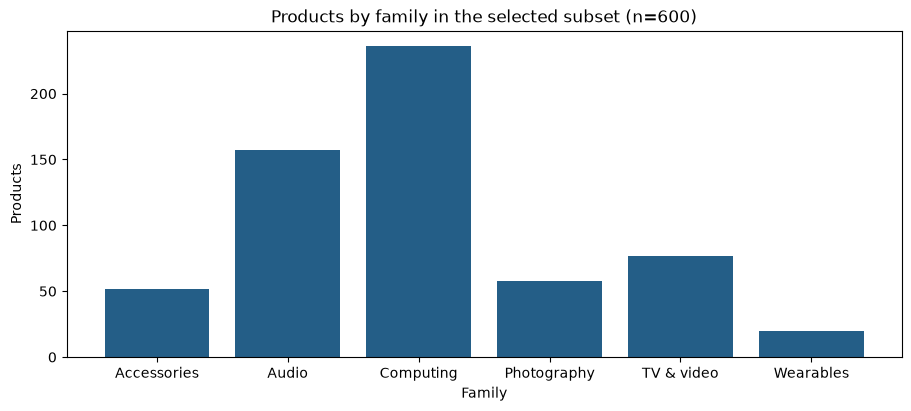

In [7]:
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
ax.bar(family_counts.index, family_counts.values, color="#245E87")
ax.set_title("Products by family in the selected subset (n=600)")
ax.set_xlabel("Family")
ax.set_ylabel("Products")
plt.show()


Las familias tienen distintos tamaños porque algunas agotan sus candidatos antes.
Esta selección permite explorar diversidad; no reproduce todo el catálogo.


## 6. Reconocer valoraciones y tamaños de muestra

Las estadísticas describen **estas reseñas seleccionadas**. Una media basada en
cinco opiniones requiere más cautela que una basada en treinta; el conteo no mide
la popularidad del producto en Amazon.


In [8]:
has_text = reviews_df["text"].str.strip().ne("")
reviews_per_product = reviews_df.groupby("product_id").size()
print("Reviews with text:", int(has_text.sum()))
print("Unique review IDs:", reviews_df["review_id"].is_unique)
print("Minimum reviews:", int(reviews_per_product.min()))
print("Maximum reviews:", int(reviews_per_product.max()))
print("Missing values:")
print(reviews_df.isna().sum())


Reviews with text: 6992
Unique review IDs: True
Minimum reviews: 5
Maximum reviews: 30
Missing values:
review_id     0
product_id    0
text          0
rating        0
dtype: int64


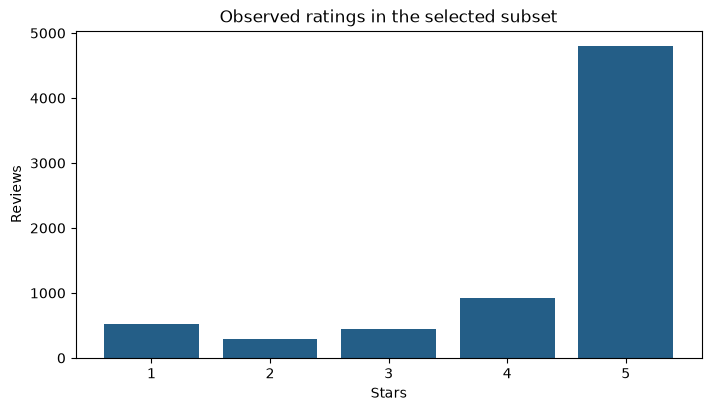

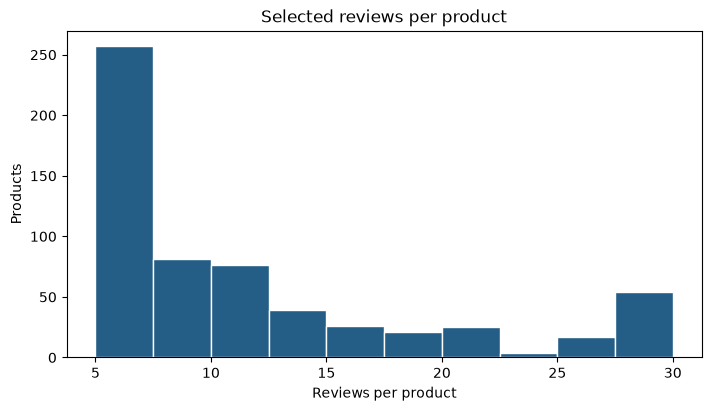

In [9]:
rating_counts = reviews_df["rating"].value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.bar(rating_counts.index, rating_counts.values, color="#245E87")
ax.set_title("Observed ratings in the selected subset")
ax.set_xlabel("Stars")
ax.set_ylabel("Reviews")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.hist(reviews_per_product, bins=10, color="#245E87", edgecolor="white")
ax.set_title("Selected reviews per product")
ax.set_xlabel("Reviews per product")
ax.set_ylabel("Products")
plt.show()


In [10]:
example_product = "B0BCTJMN63"
example_reviews = review_catalog.loc[review_catalog["product_id"] == example_product]
print("Product ID:", example_product)
print("Title:", products[example_product]["title"])
print("Review count:", len(example_reviews))
print("Observed mean:", example_reviews["rating"].mean())
print("Observed median:", example_reviews["rating"].median())


Product ID: B0BCTJMN63
Title: JBL CHARGE 5 - Portable Bluetooth Speaker with IP67 Waterproof and USB Charge out - Black
Review count: 7
Observed mean: 4.571428571428571
Observed median: 5.0


## 7. Preparar textos para embeddings

Conserva el orden de textos e IDs. Continúa con la [guía de embeddings](./GUIA.md#3-generar-los-embeddings-para-la-búsqueda)
para combinar catálogo y reseñas; mantén las valoraciones separadas.


In [11]:
searchable_reviews = reviews_df.loc[has_text].copy()
texts: list[str] = searchable_reviews["text"].str.strip().tolist()
review_ids: list[str] = searchable_reviews["review_id"].tolist()
review_product_ids: list[str] = searchable_reviews["product_id"].tolist()
print("Texts to encode:", len(texts))
print("First review ID:", review_ids[0])
print("First product ID:", review_product_ids[0])


Texts to encode: 6992
First review ID: Electronics:1039
First product ID: B0000BYDKO


## 8. Cómo se preparó la selección · referencia opcional

El código está proporcionado completo; **no necesitas ejecutarlo para la entrega**.
Los criterios y las fuentes están en [DATASET.md](./DATASET.md#diversidad-y-selección).

`read_source()` lee registros remotos uno a uno hasta `limit`. Los diccionarios
agrupan reseñas y candidatos por producto; las listas y los bucles aplican los
límites y los turnos entre familias. `write_jsonl()` guarda un objeto por línea.
Regenerar los archivos requiere más red y tiempo que usar la selección incluida.


In [12]:
BASE_URL = "https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw"
SOURCE_URLS = {
    "reviews": f"{BASE_URL}/review_categories/Electronics.jsonl.gz",
    "products": f"{BASE_URL}/meta_categories/meta_Electronics.jsonl.gz",
}
FAMILY_MAP = {
    "Computers & Accessories": "Computing",
    "Computers": "Computing",
    "Headphones, Earbuds & Accessories": "Audio",
    "Portable Audio & Video": "Audio",
    "Home Audio": "Audio",
    "Television & Video": "TV & video",
    "Camera & Photo": "Photography",
    "Accessories & Supplies": "Accessories",
    "Wearable Technology": "Wearables",
}


def product_family(product: dict[str, Any]) -> str | None:
    categories = product.get("categories") or []
    branch = categories[1] if len(categories) > 1 else product.get("main_category")
    return FAMILY_MAP.get(branch)


def read_source(url: str, limit: int) -> Iterator[tuple[int, dict[str, Any]]]:
    with urllib.request.urlopen(url, timeout=120) as response:
        with gzip.open(response, "rt", encoding="utf-8") as stream:
            for line_number, line in enumerate(stream, start=1):
                yield line_number, json.loads(line)
                if line_number >= limit:
                    break


def write_jsonl(path: Path, records: list[dict[str, Any]]) -> None:
    with gzip.open(path, "wt", encoding="utf-8") as output:
        for record in records:
            output.write(json.dumps(record, ensure_ascii=False) + "\n")


def prepare_sample(directory: Path, product_limit: int = 600) -> None:
    if not 1 <= product_limit <= 600:
        raise ValueError("product_limit must be between 1 and 600")
    reviews_by_product: dict[str, list[dict[str, Any]]] = {}
    for line_number, review in read_source(SOURCE_URLS["reviews"], 250_000):
        product_id = review.get("parent_asin")
        rating = review.get("rating")
        text = review.get("text") or ""
        if not isinstance(product_id, str) or not product_id:
            continue
        if isinstance(rating, bool) or rating not in (1, 2, 3, 4, 5):
            continue
        if not isinstance(text, str) or not text.strip():
            continue
        selected = reviews_by_product.setdefault(product_id, [])
        if len(selected) < 30:
            selected.append({
                "parent_asin": product_id,
                "rating": rating,
                "text": text,
                "source_line": line_number,
            })

    candidates: dict[str, list[dict[str, Any]]] = {}
    for _, product in read_source(SOURCE_URLS["products"], 50_000):
        product_id = product.get("parent_asin")
        family = product_family(product)
        title = product.get("title") or ""
        if family is None or len(reviews_by_product.get(product_id, [])) < 5:
            continue
        if not isinstance(title, str) or not title.strip():
            continue
        candidates.setdefault(family, []).append({
            "parent_asin": product_id,
            "title": title,
            "features": product.get("features") or [],
            "description": product.get("description") or [],
            "categories": product.get("categories") or [],
            "family": family,
        })

    for family in sorted(candidates):
        candidates[family].sort(key=lambda product: product["parent_asin"], reverse=True)
    selected_products: list[dict[str, Any]] = []
    while len(selected_products) < product_limit:
        before = len(selected_products)
        for family in sorted(candidates):
            if candidates[family] and len(selected_products) < product_limit:
                selected_products.append(candidates[family].pop())
        if len(selected_products) == before:
            raise ValueError("Not enough eligible products in the source window")
    selected_reviews = [
        review
        for product in selected_products
        for review in reviews_by_product[product["parent_asin"]]
    ]
    directory.mkdir(parents=True, exist_ok=True)
    write_jsonl(directory / "products.jsonl.gz", selected_products)
    write_jsonl(directory / "reviews.jsonl.gz", selected_reviews)
    print(f"Prepared {len(selected_products)} products and {len(selected_reviews)} reviews")


In [13]:
# Optional: recreate the subset in a separate folder.
# prepare_sample(Path("datasets_rebuilt"))
